# MVP-2 — Experimento 3: Encoder Metilación PCA+MLP
**Fecha:** Abril 2026 | **Autor:** JCB | **Proyecto:** Inferencia del envejecimiento celular

---

**Objetivo:** Entrenar un MLP que mapee 10K CpGs → PCA → z_met (256-dim) → PDL_hat

**Decisiones incorporadas:**
1. PCA obligatorio antes de MLP (baseline confirma: +0.060 Spearman vs crudo)
2. Two-stage PRETRAIN → FINETUNE (mismo esquema que Exp 2 RNA)
3. Capa intermedia z_met → PDL_hat (libertad geométrica para fusión)
4. Batch probe condicional CORREGIDO (sin `multi_class` deprecado)
5. Correlación con relojes epigenéticos (validación biológica clave para Met)
6. RankingLoss sobre PDL_hat (no sobre z_met)

**Baselines establecidos:**
- PCA + Elastic Net: **0.772** Spearman (upper bound)
- Met crudo Elastic Net: 0.712 (PCA mejora +0.060)
- PCA: 8 componentes capturan 85% varianza

**Targets tentativos:**
- Spearman promedio ≥ 0.695 (90% de PCA+EN)
- Worst fold ≥ 0.55 (90% de PCA worst 0.610)
- ρ(z_met, clocks) > 0.3 parcial (coherencia biológica)


## Sección 0: Configuración

In [1]:
import os, sys, json, time, copy, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Device: mps
PyTorch: 2.2.2
Timestamp: 2026-04-01 15:52


## Sección 1: Rutas y parámetros

In [2]:
# --- RUTAS (AJUSTAR) ---
DATA_DIR     = Path("/Users/JCB/Documentos/Proyecto Integrador/data/")
MANIFEST_DIR = DATA_DIR / "manifests"
RESULTS_DIR  = Path("/Users/JCB/Documentos/Proyecto Integrador/results_2/")
OUTPUT_DIR   = RESULTS_DIR / "mvp2_encoder_met"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- ARCHIVOS ---
MANIFEST_PRETRAIN = "manifest_mvp2_pretrain_20260328_143235.csv"
MANIFEST_FINETUNE = "manifest_mvp2_finetune_20260328_143235.csv"
MET_MATRIX_FILE   = "mvp2_met_selected_20260328_143235.csv.gz"

# --- HIPERPARÁMETROS ---
HP = {
    # PCA
    "pca_variance":    0.95,   # Varianza explicada (95% → ~30-80 componentes)

    # Arquitectura (input_dim se determina tras PCA)
    "hidden_dim":      256,
    "z_dim":           256,    # debe coincidir con z_img y z_rna
    "pdl_head_dim":    64,     # capa intermedia z → PDL_hat
    "dropout_input":   0.5,
    "dropout_hidden":  0.3,

    # Training - Stage 1 (PRETRAIN)
    "lr_pretrain":      1e-3,
    "wd_pretrain":      1e-4,
    "epochs_pretrain":  200,
    "patience_pretrain": 25,
    "batch_size_pretrain": 64,

    # Training - Stage 2 (FINETUNE)
    "lr_finetune":      1e-4,
    "wd_finetune":      1e-4,
    "epochs_finetune":  150,
    "patience_finetune": 20,
    "batch_size_finetune": 32,

    # Loss
    "lambda_rank":     0.5,
    "rank_margin":     0.1,

    "seed": SEED,
}

TARGETS = {
    "spearman_aspiracional": 0.695,  # 90% del PCA+EN (0.772)
    "spearman_piso":         0.55,
    "worst_fold_aspiracional": 0.55, # 90% del PCA worst (0.610)
    "worst_fold_piso":         0.45,
    "delta_auc_condicional":   0.10,
    "overfitting_gap":         0.15,
    "clock_rho_parcial":       0.30, # coherencia biológica
}

print("Hiperparámetros:")
for k, v in HP.items():
    print(f"  {k}: {v}")
print(f"\nTargets:")
for k, v in TARGETS.items():
    print(f"  {k}: {v}")

Hiperparámetros:
  pca_variance: 0.95
  hidden_dim: 256
  z_dim: 256
  pdl_head_dim: 64
  dropout_input: 0.5
  dropout_hidden: 0.3
  lr_pretrain: 0.001
  wd_pretrain: 0.0001
  epochs_pretrain: 200
  patience_pretrain: 25
  batch_size_pretrain: 64
  lr_finetune: 0.0001
  wd_finetune: 0.0001
  epochs_finetune: 150
  patience_finetune: 20
  batch_size_finetune: 32
  lambda_rank: 0.5
  rank_margin: 0.1
  seed: 42

Targets:
  spearman_aspiracional: 0.695
  spearman_piso: 0.55
  worst_fold_aspiracional: 0.55
  worst_fold_piso: 0.45
  delta_auc_condicional: 0.1
  overfitting_gap: 0.15
  clock_rho_parcial: 0.3


## Sección 2: Carga de datos

In [4]:
print("=" * 70)
print("SECCIÓN 2: Carga de datos")
print("=" * 70)

manifest_pre = pd.read_csv(MANIFEST_DIR / MANIFEST_PRETRAIN)
manifest_ft  = pd.read_csv(MANIFEST_DIR / MANIFEST_FINETUNE)
print(f"Manifest PRETRAIN: {manifest_pre.shape}")
print(f"Manifest FINETUNE: {manifest_ft.shape}")

pre_met = manifest_pre[manifest_pre['has_met'] == True].copy()
ft_met  = manifest_ft[manifest_ft['has_met'] == True].copy()
print(f"PRETRAIN con Met: {len(pre_met)}")
print(f"FINETUNE con Met: {len(ft_met)}")

# Cargar matriz de metilación
met_raw = pd.read_csv(MANIFEST_DIR/ MET_MATRIX_FILE, compression='gzip', index_col=0)
print(f"Matriz Met raw: {met_raw.shape}")

# Determinar orientación: si filas ≈ 10K → CpGs como filas, transponer
if met_raw.shape[0] > met_raw.shape[1]:
    met_matrix = met_raw.T  # ahora: muestras × CpGs
    print(f"Transpuesta: {met_matrix.shape} (muestras × CpGs)")
else:
    met_matrix = met_raw
    print(f"Ya orientada: {met_matrix.shape} (muestras × CpGs)")

n_cpgs = met_matrix.shape[1]
print(f"Total CpGs: {n_cpgs}")

# La columna met_matrix_col tiene formato "203784950011_R01C01 beta"
# Los índices/columnas de la matriz pueden tener o no el sufijo " beta"
# Intentar merge directo, si falla limpiar
met_matrix_idx = met_matrix.copy()
met_matrix_idx.index.name = 'met_matrix_col'
met_matrix_idx = met_matrix_idx.reset_index()

# Intentar merge
df_pre_test = pre_met.merge(met_matrix_idx, on='met_matrix_col', how='inner')
print(f"\nMerge test PRETRAIN: {len(df_pre_test)} de {len(pre_met)} muestras")

if len(df_pre_test) < len(pre_met) * 0.5:
    print("⚠️ Merge bajo — intentando limpiar sufijo ' beta'...")
    # Limpiar met_matrix_col en manifest (quitar " beta" si existe)
    pre_met['met_matrix_col_clean'] = pre_met['met_matrix_col'].str.replace(' beta', '', regex=False)
    ft_met['met_matrix_col_clean'] = ft_met['met_matrix_col'].str.replace(' beta', '', regex=False)
    # O limpiar en matriz
    met_matrix_idx['met_matrix_col_clean'] = met_matrix_idx['met_matrix_col'].str.replace(' beta', '', regex=False)
    df_pre = pre_met.merge(met_matrix_idx, left_on='met_matrix_col_clean', right_on='met_matrix_col_clean', how='inner', suffixes=('', '_mat'))
    df_ft  = ft_met.merge(met_matrix_idx, left_on='met_matrix_col_clean', right_on='met_matrix_col_clean', how='inner', suffixes=('', '_mat'))
else:
    df_pre = pre_met.merge(met_matrix_idx, on='met_matrix_col', how='inner')
    df_ft  = ft_met.merge(met_matrix_idx, on='met_matrix_col', how='inner')

# Identificar columnas de CpGs (numéricas que no son metadata)
metadata_cols = set(manifest_pre.columns)
cpg_cols = [c for c in df_pre.columns if c not in metadata_cols and c != 'met_matrix_col_clean']
# Filtrar solo columnas numéricas
cpg_cols = [c for c in cpg_cols if df_pre[c].dtype in ['float64', 'float32', 'int64']]
print(f"CpG columns detectadas: {len(cpg_cols)}")

# Si no detectamos suficientes, usar las columnas de la matriz original
if len(cpg_cols) < 1000:
    print("Usando columnas de la matriz original...")
    cpg_cols = [c for c in met_matrix.columns.tolist() if c in df_pre.columns]
    print(f"CpG columns (from matrix): {len(cpg_cols)}")

# Limpiar NaN
df_pre = df_pre.dropna(subset=['pdl_norm', 'fold'])
df_ft  = df_ft.dropna(subset=['pdl_norm', 'fold'])

print(f"\nDatos merged finales:")
print(f"  PRETRAIN: {len(df_pre)} muestras × {len(cpg_cols)} CpGs")
print(f"  FINETUNE: {len(df_ft)} muestras")

for stage_name, df_s in [("PRETRAIN", df_pre), ("FINETUNE", df_ft)]:
    print(f"\n  {stage_name} por fold:")
    for fold in sorted(df_s['fold'].unique()):
        n = (df_s['fold'] == fold).sum()
        pdl_mean = df_s[df_s['fold'] == fold]['pdl_norm'].mean()
        print(f"    Fold {int(fold)}: {n:>4} muestras, PDL mean={pdl_mean:.3f}")

SECCIÓN 2: Carga de datos
Manifest PRETRAIN: (715, 50)
Manifest FINETUNE: (161, 50)
PRETRAIN con Met: 479
FINETUNE con Met: 118
Matriz Met raw: (479, 10000)
Ya orientada: (479, 10000) (muestras × CpGs)
Total CpGs: 10000

Merge test PRETRAIN: 0 de 479 muestras
⚠️ Merge bajo — intentando limpiar sufijo ' beta'...
CpG columns detectadas: 10000

Datos merged finales:
  PRETRAIN: 479 muestras × 10000 CpGs
  FINETUNE: 118 muestras

  PRETRAIN por fold:
    Fold 0:  143 muestras, PDL mean=0.413
    Fold 1:  196 muestras, PDL mean=0.465
    Fold 2:  140 muestras, PDL mean=0.560

  FINETUNE por fold:
    Fold 0:   40 muestras, PDL mean=0.390
    Fold 1:   49 muestras, PDL mean=0.421
    Fold 2:   29 muestras, PDL mean=0.563


## Sección 3: PCA sobre metilación

**PCA es obligatorio** (baseline: +0.060 Spearman sobre crudo).
Se usa `n_components=0.95` (95% varianza explicada) para retener más
información que el baseline (que usó 85% → 8 componentes), dando al
MLP más señal para aprender representaciones ricas.

El PCA se fitea **por fold** en el train set y se aplica al val set.


SECCIÓN 3: PCA sobre metilación
PCA exploratoria (todo PRETRAIN):
  Varianza target: 95%
  Componentes: 23
  Varianza real: 95.2%
  Input al MLP será: 23 dimensiones


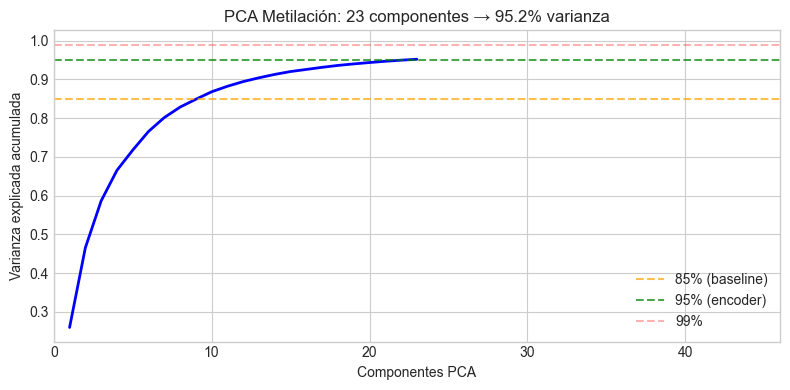

In [5]:
print("=" * 70)
print("SECCIÓN 3: PCA sobre metilación")
print("=" * 70)

# Verificar cuántos componentes da 95% varianza (exploración global)
X_all = df_pre[cpg_cols].values.astype(np.float32)

# Reemplazar NaN con mediana por columna
from sklearn.impute import SimpleImputer
imputer_check = SimpleImputer(strategy='median')
X_all_clean = imputer_check.fit_transform(X_all)

scaler_check = StandardScaler()
X_scaled = scaler_check.fit_transform(X_all_clean)

pca_check = PCA(n_components=HP['pca_variance'], random_state=SEED)
X_pca_check = pca_check.fit_transform(X_scaled)

n_components_95 = pca_check.n_components_
var_explained = pca_check.explained_variance_ratio_.sum()

print(f"PCA exploratoria (todo PRETRAIN):")
print(f"  Varianza target: {HP['pca_variance']*100:.0f}%")
print(f"  Componentes: {n_components_95}")
print(f"  Varianza real: {var_explained*100:.1f}%")
print(f"  Input al MLP será: {n_components_95} dimensiones")

# Actualizar HP con input_dim real
HP['input_dim'] = n_components_95

# Plot varianza explicada acumulada
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
cumvar = np.cumsum(pca_check.explained_variance_ratio_)
ax.plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
ax.axhline(y=0.85, color='orange', linestyle='--', alpha=0.7, label='85% (baseline)')
ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% (encoder)')
ax.axhline(y=0.99, color='red', linestyle='--', alpha=0.3, label='99%')
ax.set_xlabel('Componentes PCA')
ax.set_ylabel('Varianza explicada acumulada')
ax.set_title(f'PCA Metilación: {n_components_95} componentes → {var_explained*100:.1f}% varianza')
ax.legend()
ax.set_xlim(0, min(100, n_components_95 * 2))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "pca_variance_explained.png" if (OUTPUT_DIR / "plots").exists()
            else OUTPUT_DIR / "pca_variance_explained.png", dpi=150)
plt.show()

del X_all, X_all_clean, X_scaled, X_pca_check, pca_check, scaler_check

## Sección 4: Dataset y DataLoader

In [6]:
print("=" * 70)
print("SECCIÓN 4: Dataset y DataLoader")
print("=" * 70)

class MetDataset(Dataset):
    """Dataset para metilación PCA-reducida + PDL."""

    def __init__(self, df, cpg_cols, pca=None, scaler=None, imputer=None,
                 fit_preprocessing=False):
        self.pdl = torch.tensor(df['pdl_norm'].values, dtype=torch.float32)
        self.sample_ids = df['sample_id'].values if 'sample_id' in df.columns else np.arange(len(df))
        self.study_part = df['study_part'].values if 'study_part' in df.columns else None
        self.cell_line = df['cell_line'].values if 'cell_line' in df.columns else None

        X = df[cpg_cols].values.astype(np.float32)

        if fit_preprocessing:
            self.imputer = SimpleImputer(strategy='median')
            X = self.imputer.fit_transform(X)
            self.scaler = StandardScaler()
            X = self.scaler.fit_transform(X)
            self.pca = PCA(n_components=HP['pca_variance'], random_state=SEED)
            X = self.pca.fit_transform(X)
        else:
            self.imputer = imputer
            self.scaler = scaler
            self.pca = pca
            if imputer is not None:
                X = imputer.transform(X)
            if scaler is not None:
                X = scaler.transform(X)
            if pca is not None:
                X = pca.transform(X)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.input_dim = self.X.shape[1]

    def __len__(self):
        return len(self.pdl)

    def __getitem__(self, idx):
        return self.X[idx], self.pdl[idx]


def build_met_loaders(df, cpg_cols, fold_val, batch_size, stage="pretrain"):
    train_mask = df['fold'] != fold_val
    val_mask   = df['fold'] == fold_val
    df_train = df[train_mask].reset_index(drop=True)
    df_val   = df[val_mask].reset_index(drop=True)

    ds_train = MetDataset(df_train, cpg_cols, fit_preprocessing=True)
    ds_val   = MetDataset(df_val, cpg_cols,
                          pca=ds_train.pca, scaler=ds_train.scaler,
                          imputer=ds_train.imputer)

    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                              drop_last=len(ds_train) > batch_size)
    loader_val   = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    print(f"  [{stage}] Fold {int(fold_val)}: train={len(ds_train)}, val={len(ds_val)}, "
          f"PCA dims={ds_train.input_dim}")

    return loader_train, loader_val, ds_train.pca, ds_train.scaler, ds_train.imputer

print("Dataset y DataLoader definidos ✓")

SECCIÓN 4: Dataset y DataLoader
Dataset y DataLoader definidos ✓


## Sección 5: Modelo — Met Encoder PCA+MLP

In [7]:
print("=" * 70)
print("SECCIÓN 5: Modelo")
print("=" * 70)

class MetEncoder(nn.Module):
    """
    PCA+MLP encoder: Met PCA(~N) → z_met (256) → PDL_hat

    Arquitectura:
      PCA(N) → Dropout(0.5) → Linear(256) → ReLU → Dropout(0.3)
             → Linear(256) = z_met
             → Linear(64) → ReLU → Linear(1) = PDL_hat
    """

    def __init__(self, input_dim, hidden_dim=256, z_dim=256,
                 pdl_head_dim=64, dropout_input=0.5, dropout_hidden=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Dropout(dropout_input),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_hidden),
            nn.Linear(hidden_dim, z_dim),
        )
        self.pdl_head = nn.Sequential(
            nn.Linear(z_dim, pdl_head_dim),
            nn.ReLU(),
            nn.Linear(pdl_head_dim, 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        pdl_hat = self.pdl_head(z).squeeze(-1)
        return z, pdl_hat

    def encode(self, x):
        with torch.no_grad():
            return self.encoder(x)

# Test
model_test = MetEncoder(input_dim=HP['input_dim'], hidden_dim=HP['hidden_dim'],
                         z_dim=HP['z_dim'], pdl_head_dim=HP['pdl_head_dim'])
x_test = torch.randn(4, HP['input_dim'])
z_test, p_test = model_test(x_test)
n_params = sum(p.numel() for p in model_test.parameters())
print(f"Input PCA dims: {HP['input_dim']}")
print(f"z_met: {z_test.shape}, PDL_hat: {p_test.shape}")
print(f"Parámetros: {n_params:,}")
print(f"\n{model_test}")
del model_test, x_test, z_test, p_test

SECCIÓN 5: Modelo
Input PCA dims: 23
z_met: torch.Size([4, 256]), PDL_hat: torch.Size([4])
Parámetros: 88,449

MetEncoder(
  (encoder): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=23, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
  )
  (pdl_head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Sección 6: Loss Functions

In [13]:
print("=" * 70)
print("SECCIÓN 6: Loss Functions")
print("=" * 70)

class RankingLoss(nn.Module):
    def __init__(self, margin=0.1):
        super().__init__()
        self.margin = margin

    def forward(self, pdl_hat, pdl_true):
        n = len(pdl_hat)
        if n < 2:
            return torch.tensor(0.0, device=pdl_hat.device)
        n_pairs = min(n * 2, 256)
        idx_a = torch.randint(0, n, (n_pairs,), device=pdl_hat.device)
        idx_b = torch.randint(0, n, (n_pairs,), device=pdl_hat.device)
        diff_true = pdl_true[idx_a] - pdl_true[idx_b]
        valid = diff_true.abs() > 0.01
        if valid.sum() < 2:
            return torch.tensor(0.0, device=pdl_hat.device)
        idx_a, idx_b = idx_a[valid], idx_b[valid]
        diff_true = diff_true[valid]
        diff_hat = pdl_hat[idx_a] - pdl_hat[idx_b]
        target = torch.sign(diff_true)
        loss = torch.clamp(self.margin - target * diff_hat, min=0)
        return loss.mean()

class CombinedLoss(nn.Module):
    def __init__(self, lambda_rank=0.5, rank_margin=0.1):
        super().__init__()
        self.mse = nn.MSELoss()
        self.ranking = RankingLoss(margin=rank_margin)
        self.lambda_rank = lambda_rank

    def forward(self, pdl_hat, pdl_true):
        l_mse = self.mse(pdl_hat, pdl_true)
        l_rank = self.ranking(pdl_hat, pdl_true)
        return l_mse + self.lambda_rank * l_rank, l_mse.item(), l_rank.item()

print("Loss functions definidas ✓")
print(f"  λ_rank = {HP['lambda_rank']}, margin = {HP['rank_margin']}")

SECCIÓN 6: Loss Functions
Loss functions definidas ✓
  λ_rank = 0.5, margin = 0.1


## Sección 7: Training Infrastructure

In [14]:
print("=" * 70)
print("SECCIÓN 7: Training Infrastructure")
print("=" * 70)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_mse, total_rank = 0, 0, 0
    all_hat, all_true = [], []
    for X, pdl in loader:
        X, pdl = X.to(device), pdl.to(device)
        z, pdl_hat = model(X)
        loss, mse_v, rank_v = criterion(pdl_hat, pdl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X)
        total_mse += mse_v * len(X)
        total_rank += rank_v * len(X)
        all_hat.extend(pdl_hat.detach().cpu().numpy())
        all_true.extend(pdl.cpu().numpy())
    n = len(all_hat)
    rho, _ = stats.spearmanr(all_hat, all_true)
    return {'loss': total_loss/n, 'mse': total_mse/n, 'rank': total_rank/n, 'spearman': rho}

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_mse, total_rank = 0, 0, 0
    all_hat, all_true, all_z = [], [], []
    for X, pdl in loader:
        X, pdl = X.to(device), pdl.to(device)
        z, pdl_hat = model(X)
        loss, mse_v, rank_v = criterion(pdl_hat, pdl)
        total_loss += loss.item() * len(X)
        total_mse += mse_v * len(X)
        total_rank += rank_v * len(X)
        all_hat.extend(pdl_hat.cpu().numpy())
        all_true.extend(pdl.cpu().numpy())
        all_z.append(z.cpu().numpy())
    n = len(all_hat)
    rho, _ = stats.spearmanr(all_hat, all_true)
    mae = np.mean(np.abs(np.array(all_hat) - np.array(all_true)))
    ss_res = np.sum((np.array(all_hat) - np.array(all_true))**2)
    ss_tot = np.sum((np.array(all_true) - np.mean(all_true))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    return {'loss': total_loss/n, 'mse': total_mse/n, 'spearman': rho, 'mae': mae,
            'r2': r2, 'pdl_hat': np.array(all_hat), 'pdl_true': np.array(all_true),
            'z': np.concatenate(all_z, axis=0)}

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, device, epochs, patience, stage_name="train"):
    best_rho, best_epoch, best_state, no_improve = -1, 0, None, 0
    history = {'train_loss':[], 'val_loss':[], 'train_spearman':[], 'val_spearman':[]}

    print(f"\n  [{stage_name}] Training up to {epochs} ep (patience={patience})...")
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tm = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vm = eval_one_epoch(model, val_loader, criterion, device)
        if scheduler: scheduler.step(vm['spearman'])

        history['train_loss'].append(tm['loss']); history['val_loss'].append(vm['loss'])
        history['train_spearman'].append(tm['spearman']); history['val_spearman'].append(vm['spearman'])

        if vm['spearman'] > best_rho:
            best_rho = vm['spearman']; best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1 or no_improve == 0:
            gap = tm['spearman'] - vm['spearman']
            print(f"    Ep {epoch:>3d} | Train ρ={tm['spearman']:.3f} Val ρ={vm['spearman']:.3f} "
                  f"Gap={gap:+.3f} | MSE={vm['mse']:.4f} | {time.time()-t0:.1f}s"
                  f"{'  ★' if no_improve == 0 else ''}")

        if no_improve >= patience:
            print(f"    Early stop ep {epoch} (best={best_epoch}, ρ={best_rho:.4f})")
            break

    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch; history['best_val_spearman'] = best_rho
    return best_state, history

print("Training infrastructure definida ✓")

SECCIÓN 7: Training Infrastructure
Training infrastructure definida ✓


## Sección 8: Two-Stage Training (PRETRAIN → FINETUNE)

Mismo esquema que Exp 2 RNA:
- **Stage 1 (PRETRAIN):** Todas las muestras Met con PDL (todos treatments). Aprende representación general.
- **Stage 2 (FINETUNE):** Solo Control+Normal. Recalibra para señal limpia de aging.

Met tiene más muestras que RNA (479 vs 345), lo cual da más margen contra overfitting.


In [15]:
print("=" * 70)
print("SECCIÓN 8: Two-Stage Training")
print("=" * 70)

folds = sorted(df_pre['fold'].dropna().unique())
print(f"Folds: {folds}")

all_results = {}
(OUTPUT_DIR / "plots").mkdir(exist_ok=True)

for fold_val in folds:
    fold_int = int(fold_val)
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_int} (validación)")
    print(f"{'='*60}")

    # --- STAGE 1: PRETRAIN ---
    print(f"\n  --- Stage 1: PRETRAIN ---")
    tr_pre, vl_pre, pca_pre, sc_pre, imp_pre = build_met_loaders(
        df_pre, cpg_cols, fold_val, HP['batch_size_pretrain'], "PRETRAIN")

    actual_input_dim = tr_pre.dataset.input_dim
    model = MetEncoder(
        input_dim=actual_input_dim, hidden_dim=HP['hidden_dim'],
        z_dim=HP['z_dim'], pdl_head_dim=HP['pdl_head_dim'],
        dropout_input=HP['dropout_input'], dropout_hidden=HP['dropout_hidden']
    ).to(DEVICE)

    criterion = CombinedLoss(HP['lambda_rank'], HP['rank_margin'])
    opt_pre = optim.AdamW(model.parameters(), lr=HP['lr_pretrain'], weight_decay=HP['wd_pretrain'])
    sched_pre = optim.lr_scheduler.ReduceLROnPlateau(opt_pre, mode='max', factor=0.5, patience=10)

    state_pre, hist_pre = train_model(model, tr_pre, vl_pre, criterion, opt_pre, sched_pre,
                                       DEVICE, HP['epochs_pretrain'], HP['patience_pretrain'],
                                       f"PRE F{fold_int}")
    model.load_state_dict(state_pre)
    pre_eval = eval_one_epoch(model, vl_pre, criterion, DEVICE)
    print(f"  Stage 1: ρ={pre_eval['spearman']:.4f}, MAE={pre_eval['mae']:.4f}, R²={pre_eval['r2']:.4f}")

    # --- STAGE 2: FINETUNE ---
    print(f"\n  --- Stage 2: FINETUNE ---")
    ft_val_n = (df_ft['fold'] == fold_val).sum()
    ft_train_n = (df_ft['fold'] != fold_val).sum()
    print(f"  FINETUNE: train={ft_train_n}, val={ft_val_n}")

    if ft_train_n < 10 or ft_val_n < 5:
        print(f"  ⚠️ Insuficientes muestras. Usando PRETRAIN.")
        best_state = state_pre; hist_ft = None
        ds_ft_val = MetDataset(df_ft[df_ft['fold']==fold_val].reset_index(drop=True),
                               cpg_cols, pca=pca_pre, scaler=sc_pre, imputer=imp_pre)
        ldr_ft_val = DataLoader(ds_ft_val, batch_size=32, shuffle=False)
        ft_eval = eval_one_epoch(model, ldr_ft_val, criterion, DEVICE)
    else:
        ds_ft_tr = MetDataset(df_ft[df_ft['fold']!=fold_val].reset_index(drop=True),
                              cpg_cols, pca=pca_pre, scaler=sc_pre, imputer=imp_pre)
        ds_ft_vl = MetDataset(df_ft[df_ft['fold']==fold_val].reset_index(drop=True),
                              cpg_cols, pca=pca_pre, scaler=sc_pre, imputer=imp_pre)
        ldr_ft_tr = DataLoader(ds_ft_tr, batch_size=min(HP['batch_size_finetune'], len(ds_ft_tr)), shuffle=True)
        ldr_ft_vl = DataLoader(ds_ft_vl, batch_size=32, shuffle=False)

        opt_ft = optim.AdamW(model.parameters(), lr=HP['lr_finetune'], weight_decay=HP['wd_finetune'])
        sched_ft = optim.lr_scheduler.ReduceLROnPlateau(opt_ft, mode='max', factor=0.5, patience=8)
        best_state, hist_ft = train_model(model, ldr_ft_tr, ldr_ft_vl, criterion, opt_ft, sched_ft,
                                           DEVICE, HP['epochs_finetune'], HP['patience_finetune'],
                                           f"FT F{fold_int}")
        model.load_state_dict(best_state)
        ft_eval = eval_one_epoch(model, ldr_ft_vl, criterion, DEVICE)

    print(f"  Stage 2: ρ={ft_eval['spearman']:.4f}, MAE={ft_eval['mae']:.4f}, R²={ft_eval['r2']:.4f}")

    # Overfitting gap
    if hist_ft and hist_ft['best_epoch'] - 1 < len(hist_ft['train_spearman']):
        train_rho = hist_ft['train_spearman'][hist_ft['best_epoch']-1]
    else:
        train_rho = hist_pre['train_spearman'][min(hist_pre['best_epoch']-1, len(hist_pre['train_spearman'])-1)]
    gap = train_rho - ft_eval['spearman']
    print(f"  Gap: {gap:+.3f} (train={train_rho:.3f}, val={ft_eval['spearman']:.3f})")

    all_results[fold_int] = {
        'pre_spearman': pre_eval['spearman'], 'ft_spearman': ft_eval['spearman'],
        'ft_mae': ft_eval['mae'], 'ft_r2': ft_eval['r2'], 'overfitting_gap': gap,
        'train_spearman': train_rho,
        'z_val': ft_eval['z'], 'pdl_hat_val': ft_eval['pdl_hat'], 'pdl_true_val': ft_eval['pdl_true'],
        'history_pre': hist_pre, 'history_ft': hist_ft, 'model_state': best_state,
        'pca': pca_pre, 'scaler': sc_pre, 'imputer': imp_pre,
        'input_dim': actual_input_dim,
    }
    torch.save({'model_state_dict': best_state, 'hp': HP, 'fold': fold_int,
                'input_dim': actual_input_dim,
                'metrics': {'pre_spearman': pre_eval['spearman'], 'ft_spearman': ft_eval['spearman'],
                            'ft_mae': ft_eval['mae'], 'ft_r2': ft_eval['r2']}},
               OUTPUT_DIR / f"fold{fold_int}_model.pt")
    print(f"  Modelo guardado: fold{fold_int}_model.pt")

SECCIÓN 8: Two-Stage Training
Folds: [0.0, 1.0, 2.0]

  FOLD 0 (validación)

  --- Stage 1: PRETRAIN ---
  [PRETRAIN] Fold 0: train=336, val=143, PCA dims=19

  [PRE F0] Training up to 200 ep (patience=25)...
    Ep   1 | Train ρ=-0.006 Val ρ=0.555 Gap=-0.561 | MSE=1.0053 | 0.1s  ★
    Ep   8 | Train ρ=0.596 Val ρ=0.556 Gap=+0.040 | MSE=0.0906 | 0.1s  ★
    Ep   9 | Train ρ=0.592 Val ρ=0.771 Gap=-0.179 | MSE=0.0957 | 0.1s  ★
    Ep  10 | Train ρ=0.569 Val ρ=0.528 Gap=+0.041 | MSE=0.0964 | 0.1s
    Ep  12 | Train ρ=0.627 Val ρ=0.817 Gap=-0.190 | MSE=0.0876 | 0.1s  ★
    Ep  13 | Train ρ=0.663 Val ρ=0.843 Gap=-0.180 | MSE=0.0764 | 0.1s  ★
    Ep  15 | Train ρ=0.636 Val ρ=0.891 Gap=-0.255 | MSE=0.0775 | 0.1s  ★
    Ep  20 | Train ρ=0.653 Val ρ=0.875 Gap=-0.222 | MSE=0.0669 | 0.1s
    Ep  30 | Train ρ=0.743 Val ρ=0.882 Gap=-0.139 | MSE=0.0646 | 0.1s
    Ep  35 | Train ρ=0.788 Val ρ=0.893 Gap=-0.105 | MSE=0.0663 | 0.1s  ★
    Ep  36 | Train ρ=0.745 Val ρ=0.896 Gap=-0.151 | MSE=0.0630 | 0.1s

## Sección 9: Resumen de métricas

In [16]:
print("=" * 70)
print("SECCIÓN 9: Resumen de Métricas")
print("=" * 70)

print(f"\n{'Fold':<6}{'PRE ρ':>8}{'FT ρ':>8}{'MAE':>8}{'R²':>8}{'Gap':>8}{'N val':>8}")
print("-" * 54)
spearmans = []
for fi in sorted(all_results):
    r = all_results[fi]
    n_val = len(r['pdl_true_val'])
    print(f"  {fi:<4}{r['pre_spearman']:>8.4f}{r['ft_spearman']:>8.4f}"
          f"{r['ft_mae']:>8.4f}{r['ft_r2']:>8.4f}{r['overfitting_gap']:>+8.3f}{n_val:>8}")
    spearmans.append(r['ft_spearman'])

mean_rho = np.mean(spearmans); std_rho = np.std(spearmans)
worst_rho = np.min(spearmans); worst_fold = np.argmin(spearmans)
worst_fold_id = sorted(all_results.keys())[worst_fold]

print(f"\n  Promedio: {mean_rho:.4f} ± {std_rho:.4f}")
print(f"  Worst:    {worst_rho:.4f} (Fold {worst_fold_id})")

print(f"\n--- vs Targets ---")
for name, actual, target in [
    ("Spearman ≥ aspiracional", mean_rho, TARGETS['spearman_aspiracional']),
    ("Spearman ≥ piso", mean_rho, TARGETS['spearman_piso']),
    ("Worst fold ≥ piso", worst_rho, TARGETS['worst_fold_piso'])]:
    s = "✅" if actual >= target else "❌"
    print(f"  {s} {name}: {actual:.4f} vs {target:.4f}")

en_mean, en_worst = 0.772, 0.610
print(f"\n--- vs PCA+EN baseline ---")
print(f"  Promedio: {mean_rho:.4f} / {en_mean:.4f} = {mean_rho/en_mean*100:.1f}%")
print(f"  Worst:    {worst_rho:.4f} / {en_worst:.4f} = {worst_rho/en_worst*100:.1f}%")

SECCIÓN 9: Resumen de Métricas

Fold     PRE ρ    FT ρ     MAE      R²     Gap   N val
------------------------------------------------------
  0     0.9221  0.9710  0.1997  0.0749  -0.146      40
  1     0.1701  0.4000  0.4603 -1.7722  +0.180      49
  2     0.3701  0.3035  0.2544 -0.0479  +0.275      29

  Promedio: 0.5582 ± 0.2945
  Worst:    0.3035 (Fold 2)

--- vs Targets ---
  ❌ Spearman ≥ aspiracional: 0.5582 vs 0.6950
  ✅ Spearman ≥ piso: 0.5582 vs 0.5500
  ❌ Worst fold ≥ piso: 0.3035 vs 0.4500

--- vs PCA+EN baseline ---
  Promedio: 0.5582 / 0.7720 = 72.3%
  Worst:    0.3035 / 0.6100 = 49.8%


## Sección 10: Batch Probe (CORREGIDO)

Misma operacionalización que Exp 2, **sin `multi_class` deprecado**:
- AUC(z_met → study_part) vs AUC(PDL+cell_line → study_part)
- ΔAUC = diferencia condicional


In [17]:
print("=" * 70)
print("SECCIÓN 10: Batch Probe — study_part")
print("=" * 70)

batch_results = {}
for fi in sorted(all_results):
    r = all_results[fi]
    z_val = r['z_val']

    df_source = df_ft if (df_ft['fold'] == fi).sum() >= 5 else df_pre
    df_val = df_source[df_source['fold'] == fi].reset_index(drop=True)

    if 'study_part' not in df_val.columns or df_val['study_part'].nunique() < 2:
        print(f"  Fold {fi}: study_part no disponible o constante.")
        batch_results[fi] = {'auc_z': None, 'auc_baseline': None, 'delta': None}
        continue

    n_use = min(len(z_val), len(df_val))
    sp = df_val['study_part'].values[:n_use]
    pdl_v = df_val['pdl_norm'].values[:n_use]
    cl_v = df_val['cell_line'].values[:n_use]
    z_u = z_val[:n_use]

    valid = ~pd.isna(sp) & ~pd.isna(pdl_v)
    sp, pdl_v, cl_v, z_u = sp[valid], pdl_v[valid], cl_v[valid], z_u[valid]
    if len(np.unique(sp)) < 2:
        batch_results[fi] = {'auc_z': None, 'auc_baseline': None, 'delta': None}
        continue

    le = LabelEncoder(); cl_enc = le.fit_transform(cl_v).reshape(-1, 1)

    # AUC from z_met (NO multi_class arg — sklearn infers automatically)
    try:
        sc_z = StandardScaler(); z_sc = sc_z.fit_transform(z_u)
        clf_z = LogisticRegression(max_iter=500, C=1.0)
        clf_z.fit(z_sc, sp)
        proba_z = clf_z.predict_proba(z_sc)
        if len(np.unique(sp)) == 2:
            auc_z = roc_auc_score(sp, proba_z[:, 1])
        else:
            auc_z = roc_auc_score(sp, proba_z, multi_class='ovr', average='macro')
    except Exception as e:
        print(f"  Fold {fi}: Error AUC z: {e}"); auc_z = 0.5

    # AUC baseline: PDL + cell_line
    try:
        X_b = np.column_stack([pdl_v.reshape(-1,1), cl_enc])
        sc_b = StandardScaler(); X_bs = sc_b.fit_transform(X_b)
        clf_b = LogisticRegression(max_iter=500, C=1.0)
        clf_b.fit(X_bs, sp)
        proba_b = clf_b.predict_proba(X_bs)
        if len(np.unique(sp)) == 2:
            auc_b = roc_auc_score(sp, proba_b[:, 1])
        else:
            auc_b = roc_auc_score(sp, proba_b, multi_class='ovr', average='macro')
    except Exception as e:
        print(f"  Fold {fi}: Error AUC base: {e}"); auc_b = 0.5

    delta = auc_z - auc_b
    batch_results[fi] = {'auc_z': auc_z, 'auc_baseline': auc_b, 'delta': delta}
    print(f"  Fold {fi}: AUC(z_met)={auc_z:.3f}, AUC(PDL+cl)={auc_b:.3f}, ΔAUC={delta:+.3f}")

deltas = [v['delta'] for v in batch_results.values() if v['delta'] is not None]
if deltas:
    print(f"\n  ΔAUC promedio: {np.mean(deltas):+.3f}, máximo: {np.max(deltas):+.3f}")
    if np.max(deltas) < TARGETS['delta_auc_condicional']:
        print(f"  ✅ ΔAUC < {TARGETS['delta_auc_condicional']} → Señal limpia")
    elif np.max(deltas) < 0.20:
        print(f"  ⚠️ Contaminación moderada")
    else:
        print(f"  🔴 Contaminación alta")

SECCIÓN 10: Batch Probe — study_part
  Fold 0: AUC(z_met)=1.000, AUC(PDL+cl)=0.711, ΔAUC=+0.289
  Fold 1: AUC(z_met)=0.998, AUC(PDL+cl)=0.787, ΔAUC=+0.212
  Fold 2: AUC(z_met)=1.000, AUC(PDL+cl)=0.538, ΔAUC=+0.462

  ΔAUC promedio: +0.321, máximo: +0.462
  🔴 Contaminación alta


## Sección 11: Plots diagnósticos

SECCIÓN 11: Plots


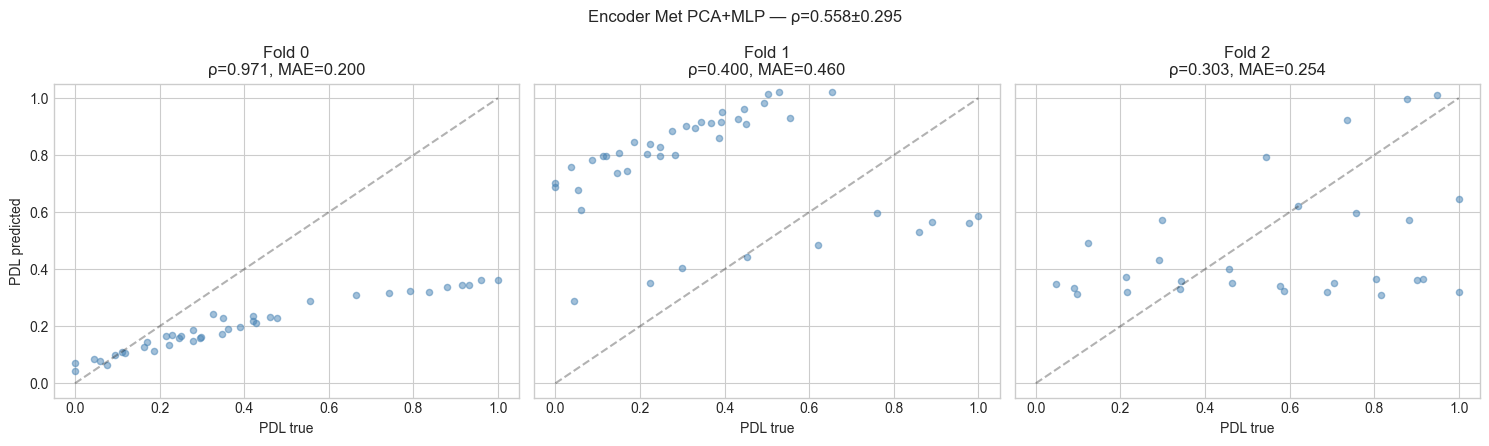

  ✓ scatter_pdl_met.png


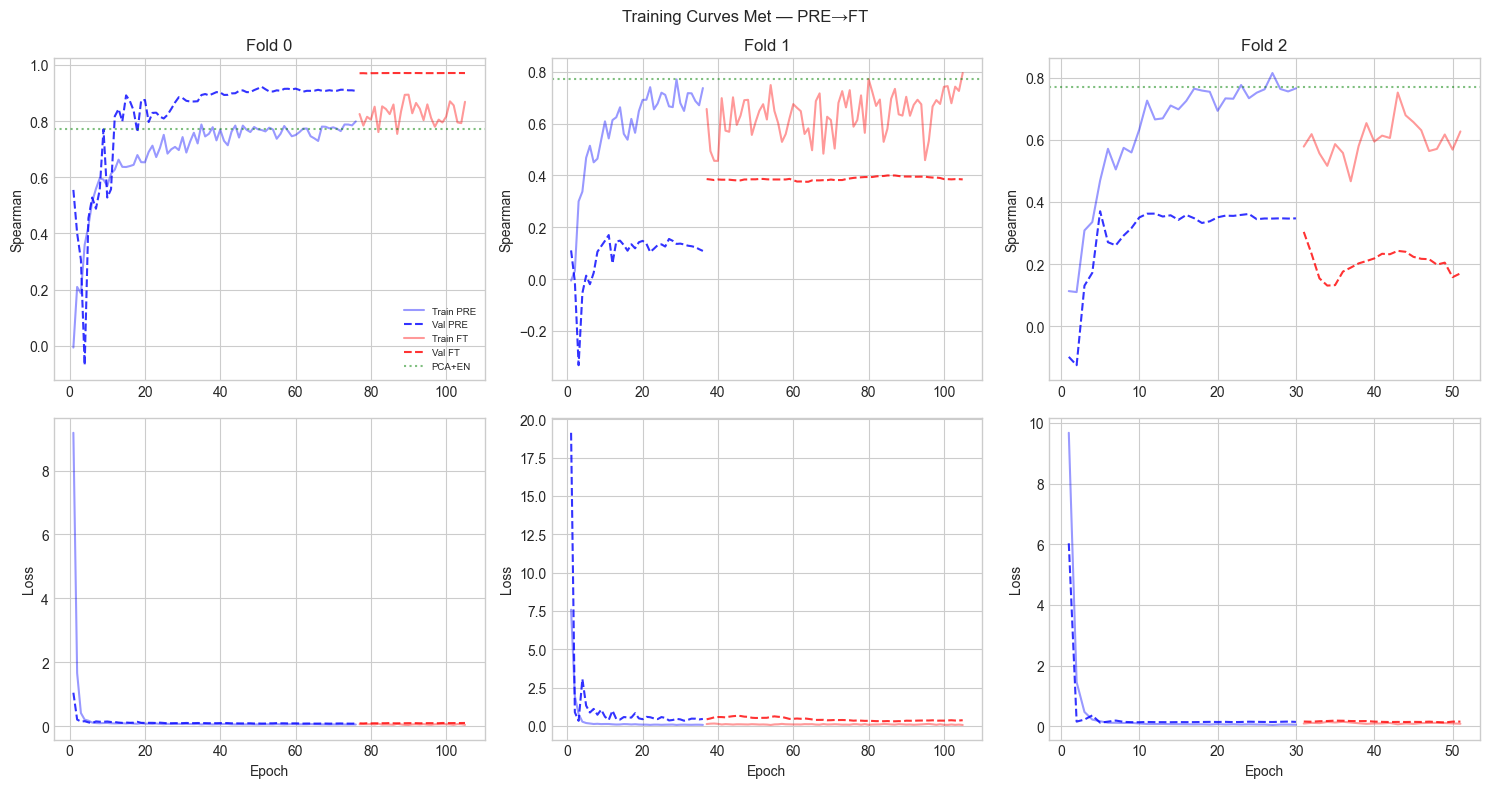

  ✓ training_curves_met.png


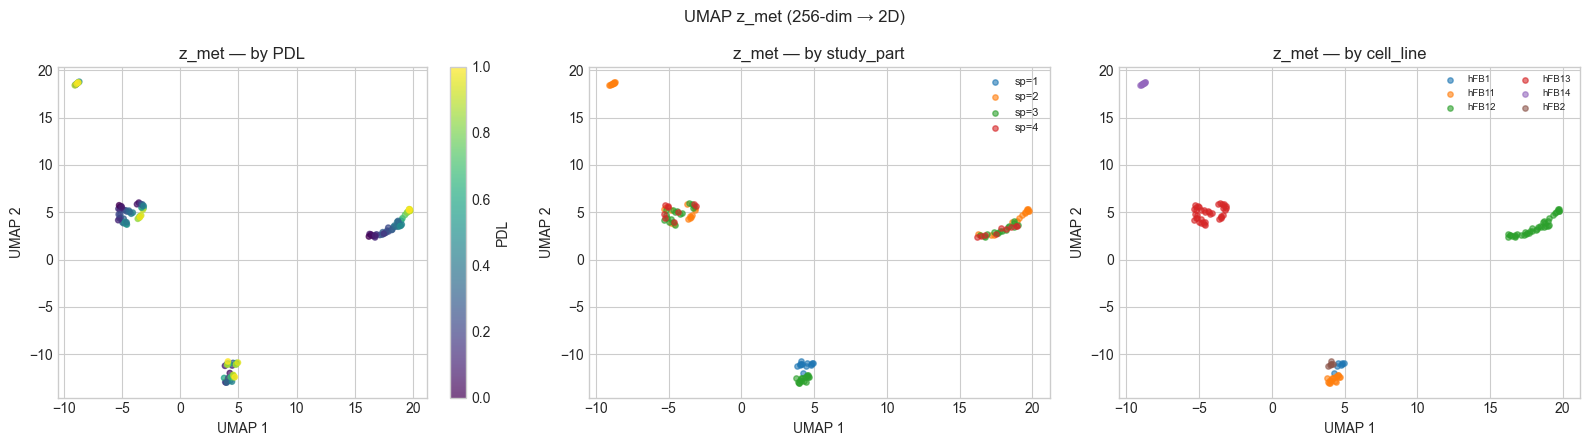

  ✓ umap_z_met.png


In [18]:
print("=" * 70)
print("SECCIÓN 11: Plots")
print("=" * 70)

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(exist_ok=True)

# 11a: Scatter PDL
fig, axes = plt.subplots(1, len(folds), figsize=(5*len(folds), 4.5), sharey=True, squeeze=False)
for i, fi in enumerate(sorted(all_results)):
    ax = axes[0][i]; r = all_results[fi]
    ax.scatter(r['pdl_true_val'], r['pdl_hat_val'], alpha=0.5, s=20, c='steelblue')
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_xlabel('PDL true'); ax.set_title(f"Fold {fi}\nρ={r['ft_spearman']:.3f}, MAE={r['ft_mae']:.3f}")
    if i==0: ax.set_ylabel('PDL predicted')
    ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
fig.suptitle(f"Encoder Met PCA+MLP — ρ={mean_rho:.3f}±{std_rho:.3f}", fontsize=12)
fig.tight_layout(); fig.savefig(plots_dir/"scatter_pdl_met.png", dpi=150); plt.show()
print("  ✓ scatter_pdl_met.png")

# 11b: Training curves
fig, axes = plt.subplots(2, len(folds), figsize=(5*len(folds), 8), squeeze=False)
for i, fi in enumerate(sorted(all_results)):
    r = all_results[fi]; h_pre = r['history_pre']
    ep_pre = range(1, len(h_pre['train_spearman'])+1)
    axes[0][i].plot(ep_pre, h_pre['train_spearman'], 'b-', alpha=0.4, label='Train PRE')
    axes[0][i].plot(ep_pre, h_pre['val_spearman'], 'b--', alpha=0.8, label='Val PRE')
    h_ft = r['history_ft']
    if h_ft:
        off = len(h_pre['train_spearman'])
        ep_ft = range(off+1, off+len(h_ft['train_spearman'])+1)
        axes[0][i].plot(ep_ft, h_ft['train_spearman'], 'r-', alpha=0.4, label='Train FT')
        axes[0][i].plot(ep_ft, h_ft['val_spearman'], 'r--', alpha=0.8, label='Val FT')
    axes[0][i].axhline(y=0.772, color='green', ls=':', alpha=0.5, label='PCA+EN')
    axes[0][i].set_title(f'Fold {fi}'); axes[0][i].set_ylabel('Spearman')
    if i==0: axes[0][i].legend(fontsize=7)
    axes[1][i].plot(ep_pre, h_pre['train_loss'], 'b-', alpha=0.4)
    axes[1][i].plot(ep_pre, h_pre['val_loss'], 'b--', alpha=0.8)
    if h_ft:
        axes[1][i].plot(ep_ft, h_ft['train_loss'], 'r-', alpha=0.4)
        axes[1][i].plot(ep_ft, h_ft['val_loss'], 'r--', alpha=0.8)
    axes[1][i].set_ylabel('Loss'); axes[1][i].set_xlabel('Epoch')
fig.suptitle("Training Curves Met — PRE→FT", fontsize=12)
fig.tight_layout(); fig.savefig(plots_dir/"training_curves_met.png", dpi=150); plt.show()
print("  ✓ training_curves_met.png")

# 11c: UMAP
try:
    from umap import UMAP
    z_all = np.concatenate([all_results[fi]['z_val'] for fi in sorted(all_results)], axis=0)
    pdl_all = np.concatenate([all_results[fi]['pdl_true_val'] for fi in sorted(all_results)])
    sp_all, cl_all = [], []
    for fi in sorted(all_results):
        df_src = df_ft if (df_ft['fold']==fi).sum()>=5 else df_pre
        dv = df_src[df_src['fold']==fi].reset_index(drop=True)
        nz = len(all_results[fi]['z_val'])
        sp_all.extend(dv['study_part'].values[:nz]); cl_all.extend(dv['cell_line'].values[:nz])
    sp_all=np.array(sp_all); cl_all=np.array(cl_all)
    reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
    z_2d = reducer.fit_transform(z_all)
    fig, axes = plt.subplots(1,3,figsize=(16,4.5))
    sc=axes[0].scatter(z_2d[:,0],z_2d[:,1],c=pdl_all,cmap='viridis',s=15,alpha=0.7)
    plt.colorbar(sc,ax=axes[0],label='PDL'); axes[0].set_title('z_met — by PDL')
    for sv in np.unique(sp_all[~pd.isna(sp_all)]):
        m=sp_all==sv; axes[1].scatter(z_2d[m,0],z_2d[m,1],s=15,alpha=0.6,label=f'sp={int(sv)}')
    axes[1].legend(fontsize=8); axes[1].set_title('z_met — by study_part')
    for cv in np.unique(cl_all):
        m=cl_all==cv; axes[2].scatter(z_2d[m,0],z_2d[m,1],s=15,alpha=0.6,label=cv)
    axes[2].legend(fontsize=7,ncol=2); axes[2].set_title('z_met — by cell_line')
    for ax in axes: ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    fig.suptitle("UMAP z_met (256-dim → 2D)"); fig.tight_layout()
    fig.savefig(plots_dir/"umap_z_met.png",dpi=150); plt.show()
    print("  ✓ umap_z_met.png")
except ImportError:
    print("  ⚠️ umap-learn no instalado")

## Sección 12: Correlación con relojes epigenéticos

**Esta es la validación biológica más importante para el encoder Met.**
Los relojes epigenéticos (Horvath, PhenoAge, GrimAge, Hannum) se derivan
de metilación — z_met *debería* correlacionar con ellos más allá de PDL.

Si ρ_parcial(z_met, clocks | PDL) > 0.3 → z_met captura edad epigenética
complementaria a la replicativa.


In [19]:
print("=" * 70)
print("SECCIÓN 12: Correlación con relojes epigenéticos + biomarcadores")
print("=" * 70)

biomarkers = ['clock_horvath1', 'clock_phenoage', 'clock_grimage',
              'clock_hannum', 'clock_skinblood',
              'telomere_length', 'mtdna_cn']

bio_results = []
for bm in biomarkers:
    src = df_ft if bm in df_ft.columns else df_pre
    if bm not in src.columns:
        print(f"  {bm}: no encontrado. Saltando."); continue

    z_means, pdl_vals, bm_vals = [], [], []
    for fi in sorted(all_results):
        r = all_results[fi]
        dv = src[src['fold']==fi].reset_index(drop=True)
        nu = min(len(r['z_val']), len(dv))
        zm = r['z_val'][:nu].mean(axis=1)
        pv = dv['pdl_norm'].values[:nu]; bv = dv[bm].values[:nu]
        valid = ~np.isnan(bv) & ~np.isnan(pv)
        z_means.extend(zm[valid]); pdl_vals.extend(pv[valid]); bm_vals.extend(bv[valid])

    z_means=np.array(z_means); pdl_vals=np.array(pdl_vals); bm_vals=np.array(bm_vals)
    if len(z_means) < 10:
        print(f"  {bm}: n={len(z_means)} insuficiente."); continue

    rho_b, p_b = stats.spearmanr(z_means, bm_vals)
    # Partial correlation
    sl_z,it_z,_,_,_ = stats.linregress(pdl_vals, z_means)
    sl_b,it_b,_,_,_ = stats.linregress(pdl_vals, bm_vals)
    res_z = z_means - (sl_z*pdl_vals+it_z); res_b = bm_vals - (sl_b*pdl_vals+it_b)
    rho_p, p_p = stats.spearmanr(res_z, res_b)

    bio_results.append({'biomarker':bm, 'n':len(z_means), 'rho_brut':rho_b, 'p_brut':p_b,
                        'rho_parcial':rho_p, 'p_parcial':p_p})
    sig_b = "***" if p_b<0.001 else "**" if p_b<0.01 else "*" if p_b<0.05 else "ns"
    sig_p = "***" if p_p<0.001 else "**" if p_p<0.01 else "*" if p_p<0.05 else "ns"
    is_clock = "🕐" if "clock" in bm else "  "
    print(f"  {is_clock} {bm:<20} n={len(z_means):>3} | ρ_brut={rho_b:+.3f}{sig_b:>4} | "
          f"ρ_parcial={rho_p:+.3f}{sig_p:>4}")

# Check clock criterion
clock_results = [r for r in bio_results if 'clock' in r['biomarker']]
if clock_results:
    significant_clocks = [r for r in clock_results if abs(r['rho_parcial']) > TARGETS['clock_rho_parcial']
                          and r['p_parcial'] < 0.05]
    print(f"\n  Relojes con |ρ_parcial| > {TARGETS['clock_rho_parcial']} y p<0.05: "
          f"{len(significant_clocks)}/{len(clock_results)}")
    if significant_clocks:
        print(f"  ✅ Criterio clock CUMPLIDO")
        for r in significant_clocks:
            print(f"      {r['biomarker']}: ρ_parcial={r['rho_parcial']:+.3f}")
    else:
        print(f"  ⚠️ Ningún reloj supera criterio. Señal epigenética débil o mean(z) insuficiente.")

if bio_results:
    pd.DataFrame(bio_results).to_csv(OUTPUT_DIR/"correlacion_clocks_biomarcadores.csv", index=False)
    print(f"\n  ✓ correlacion_clocks_biomarcadores.csv")

SECCIÓN 12: Correlación con relojes epigenéticos + biomarcadores
  🕐 clock_horvath1       n=118 | ρ_brut=+0.311 *** | ρ_parcial=+0.276  **
  🕐 clock_phenoage       n=118 | ρ_brut=+0.306 *** | ρ_parcial=+0.253  **
  🕐 clock_grimage        n=118 | ρ_brut=+0.319 *** | ρ_parcial=+0.311 ***
  🕐 clock_hannum         n=118 | ρ_brut=+0.237  ** | ρ_parcial=+0.261  **
  clock_skinblood: no encontrado. Saltando.
     telomere_length      n=118 | ρ_brut=-0.060  ns | ρ_parcial=+0.186   *
     mtdna_cn             n=117 | ρ_brut=+0.046  ns | ρ_parcial=-0.014  ns

  Relojes con |ρ_parcial| > 0.3 y p<0.05: 1/4
  ✅ Criterio clock CUMPLIDO
      clock_grimage: ρ_parcial=+0.311

  ✓ correlacion_clocks_biomarcadores.csv


## Sección 13: Guardar embeddings y métricas

In [ ]:
print("=" * 70)
print("SECCIÓN 13: Guardar resultados")
print("=" * 70)

# Embeddings CSV
rows = []
for fi in sorted(all_results):
    r = all_results[fi]
    df_src = df_ft if (df_ft['fold']==fi).sum()>=5 else df_pre
    dv = df_src[df_src['fold']==fi].reset_index(drop=True)
    nu = min(len(r['z_val']), len(dv))
    for j in range(nu):
        row = {'sample_id': dv.iloc[j].get('sample_id',f's_{j}'), 'fold':fi,
               'pdl_true':r['pdl_true_val'][j], 'pdl_hat':r['pdl_hat_val'][j]}
        for d in range(r['z_val'].shape[1]):
            row[f'z_{d}'] = r['z_val'][j,d]
        rows.append(row)
df_emb = pd.DataFrame(rows)
df_emb.to_csv(OUTPUT_DIR/"embeddings_z_met.csv", index=False)
print(f"  ✓ Embeddings: {df_emb.shape}")

# Save PCA transformer for inference
import pickle
for fi in sorted(all_results):
    r = all_results[fi]
    with open(OUTPUT_DIR/f"fold{fi}_pca_scaler.pkl", 'wb') as f:
        pickle.dump({'pca': r['pca'], 'scaler': r['scaler'], 'imputer': r['imputer']}, f)
print(f"  ✓ PCA+Scaler guardados por fold")

# Metrics JSON
metrics = {
    "experiment": "MVP2_Exp3_Met_PCA_MLP_TwoStage",
    "date": datetime.now().isoformat(),
    "hp": HP, "targets": TARGETS,
    "summary": {"spearman_mean": float(mean_rho), "spearman_std": float(std_rho),
                "spearman_worst": float(worst_rho), "worst_fold": int(worst_fold_id)},
    "by_fold": {str(fi): {"pre":float(all_results[fi]['pre_spearman']),
                           "ft":float(all_results[fi]['ft_spearman']),
                           "mae":float(all_results[fi]['ft_mae']),
                           "r2":float(all_results[fi]['ft_r2']),
                           "gap":float(all_results[fi]['overfitting_gap'])}
                for fi in sorted(all_results)},
    "batch_probe": {str(fi):batch_results[fi] for fi in batch_results if batch_results[fi]['delta'] is not None},
    "biomarcadores": bio_results,
    "baseline": {"pca_en_mean": 0.772, "pca_en_worst": 0.610},
}
with open(OUTPUT_DIR/"metrics.json",'w') as f:
    json.dump(metrics, f, indent=2, default=str)
print(f"  ✓ metrics.json")

## Sección 14: Diagnóstico final

In [20]:
print("=" * 70)
print("SECCIÓN 14: DIAGNÓSTICO FINAL — Experimento 3 (Encoder Met)")
print("=" * 70)

print()
print("  ╔══════════════════════════════════════════════════════╗")
print("  ║  ENCODER MET PCA+MLP — RESULTADOS TWO-STAGE        ║")
print("  ╠══════════════════════════════════════════════════════╣")
print(f"  ║  PCA componentes:    {HP['input_dim']}")
print(f"  ║  Spearman promedio:  {mean_rho:.4f} ± {std_rho:.4f}")
print(f"  ║  Worst fold:         {worst_rho:.4f} (Fold {worst_fold_id})")
print(f"  ║  vs PCA+EN baseline: {mean_rho/en_mean*100:.1f}%")
print("  ╚══════════════════════════════════════════════════════╝")
print()

if mean_rho >= TARGETS['spearman_piso'] and worst_rho >= TARGETS['worst_fold_piso']:
    print("  ✅ ENCODER MET: VIABLE para fusión")
    print("     → z_met (256-dim) producido y guardado")
    print("     → Avanzar a Experimento 4 (Encoder Bio) y luego cross-modal (5a-5c)")
    if mean_rho < TARGETS['spearman_aspiracional']:
        print(f"     ⚠️ No alcanza aspiracional ({TARGETS['spearman_aspiracional']})")
elif mean_rho >= 0.40:
    print("  ⚠️ ENCODER MET: MARGINAL")
    print("     → Diagnosticar: overfitting, más componentes PCA, regularización")
else:
    print("  ❌ ENCODER MET: INSUFICIENTE")

print(f"\n--- Archivos generados ---")
for f in sorted(OUTPUT_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB")

print(f"\n{'='*70}")
print("FIN DEL EXPERIMENTO 3")
print(f"{'='*70}")

SECCIÓN 14: DIAGNÓSTICO FINAL — Experimento 3 (Encoder Met)

  ╔══════════════════════════════════════════════════════╗
  ║  ENCODER MET PCA+MLP — RESULTADOS TWO-STAGE        ║
  ╠══════════════════════════════════════════════════════╣
  ║  PCA componentes:    23
  ║  Spearman promedio:  0.5582 ± 0.2945
  ║  Worst fold:         0.3035 (Fold 2)
  ║  vs PCA+EN baseline: 72.3%
  ╚══════════════════════════════════════════════════════╝

  ⚠️ ENCODER MET: MARGINAL
     → Diagnosticar: overfitting, más componentes PCA, regularización

--- Archivos generados ---
  correlacion_clocks_biomarcadores.csv               0.6 KB
  fold0_model.pt                                   345.8 KB
  fold1_model.pt                                   346.8 KB
  fold2_model.pt                                   350.8 KB
  pca_variance_explained.png                        49.5 KB

FIN DEL EXPERIMENTO 3
